# Experiment No. 08 — AI-Based Customer Persona Generation from Marketing Data

**Course:** Digital Marketing (DIM) · KJSSE / IT / LYBTech / Sem-VII / 2026-27
**Product studied:** [Heatwave Monitor](../../README.md) — a free, real-time heatwave risk dashboard (heat index, WMO-aligned risk tiers, 7-day forecast, safety guide, shareable reports).

**Aim:** AI-based customer persona generation from marketing data.

> **Note on the data.** Heatwave Monitor has no real customer database (it is a free, keyless web app), so the dataset used here is **synthetic**. It is produced reproducibly by `scripts/generate_dataset.py` (seed 42) and mimics the app's audience: outdoor workers, students, families, planners and fitness enthusiasts. Here "spending" means monetisable engagement (premium alerts, report exports, hydration/cooling products via partners). Duplicates, missing values and inconsistent labels were injected on purpose so the cleaning step has real work to do.

## Step 1 — Install Python and the required libraries (with `uv`)

Everything is installed into this folder's own `.venv` using `uv` (no `pip`):

```bash
cd digital-marketing
uv sync                                   # installs pandas, numpy, scikit-learn, matplotlib, jupyter ...
uv run python scripts/generate_dataset.py # creates data/customers.csv
uv run jupyter lab                        # opens this notebook
```

The libraries were originally added with `uv add pandas numpy scikit-learn matplotlib jupyter nbformat nbconvert ipykernel`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42          # fixed seed so results are reproducible
np.random.seed(RANDOM_STATE)

ROOT = Path("..")          # notebook lives in notebooks/, so the project root is one level up
FIGURES = ROOT / "outputs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})
SEGMENT_COLOURS = ["#3B82F6", "#F59E0B", "#10B981", "#8B5CF6", "#EF4444"]


def save_fig(name):
    # every plot is saved as a PNG snapshot for the lab manual, then shown inline
    plt.tight_layout()
    plt.savefig(FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## Step 2 — Load the marketing dataset with pandas

In [28]:
raw = pd.read_csv(ROOT / "data" / "customers.csv")
print(f"Loaded {raw.shape[0]} rows x {raw.shape[1]} columns")
raw.head()

Loaded 740 rows x 15 columns


,customer_id,age,gender,occupation,education,annual_income,website_visits_per_month,purchase_frequency,avg_order_value,spending_score,preferred_channel,interests,city,state,country
0,HW0113,28.0,Female,Marketing Manager,Bachelor's,2319000.0,21.0,12.0,2539.0,73.0,Google Search,Running; Fitness,Ahmedabad,Gujarat,India
1,HW0636,18.0,Female,Student,Bachelor's,91000.0,17.0,4.0,163.0,28.0,Instagram,Campus Life; Fitness,Pune,Maharashtra,India
2,HW0664,33.0,m,Traffic Police,High School,257000.0,27.0,7.0,303.0,20.0,NaN,Work Safety; Heat Alerts,Pune,Maharashtra,India
3,HW0233,18.0,Female,Student,Bachelor's,92000.0,8.0,4.0,246.0,54.0,Push Notification,Fitness; Gadgets,Nagpur,Maharashtra,India
4,HW0189,19.0,Female,Student,Bachelor's,196000.0,7.0,4.0,292.0,34.0,Instagram,Campus Life; Travel,delhi,Delhi,India


## Step 3 — Explore the dataset and identify relevant attributes

The columns cover the four data types from the theory:

| Data type | Columns |
|---|---|
| **Demographic** | `age`, `gender`, `occupation`, `education`, `annual_income` |
| **Geographic** | `city`, `state`, `country` |
| **Behavioural** | `spending_score`, `purchase_frequency`, `website_visits_per_month`, `avg_order_value`, `preferred_channel` |
| **Psychographic** | `interests` (two interests per user) |

In [29]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               740 non-null    str    
 1   age                       722 non-null    float64
 2   gender                    728 non-null    str    
 3   occupation                740 non-null    str    
 4   education                 740 non-null    str    
 5   annual_income             715 non-null    float64
 6   website_visits_per_month  740 non-null    float64
 7   purchase_frequency        740 non-null    float64
 8   avg_order_value           726 non-null    float64
 9   spending_score            740 non-null    float64
 10  preferred_channel         725 non-null    str    
 11  interests                 730 non-null    str    
 12  city                      740 non-null    str    
 13  state                     740 non-null    str    
 14  country              

In [30]:
raw.describe().round(1)

,age,annual_income,website_visits_per_month,purchase_frequency,avg_order_value,spending_score
count,722.0,715.0,740.0,740.0,726.0,740.0
mean,34.8,680741.3,15.4,7.2,1388.0,55.9
std,13.8,586221.5,7.9,4.9,1505.9,19.1
min,18.0,60000.0,1.0,1.0,100.0,11.0
25%,23.0,165000.0,9.0,4.0,284.0,41.0
50%,33.0,357000.0,14.0,6.0,477.5,55.0
75%,43.0,1119500.0,22.0,10.0,2107.5,70.0
max,80.0,2346000.0,38.0,25.0,6878.0,100.0


In [5]:
# quality checks BEFORE cleaning
missing_before = raw.isna().sum()
duplicates_before = raw.duplicated().sum()
print("Missing values per column (before cleaning):")
print(missing_before[missing_before > 0].to_string())
print(f"\nTotal missing cells : {missing_before.sum()}")
print(f"Duplicate rows      : {duplicates_before}")
print("\nInconsistent labels in 'gender':", sorted(raw["gender"].dropna().unique()))
print("Distinct spellings in 'city'   :", raw["city"].nunique(), "(should be 10)")
print("Distinct spellings in 'channel':", raw["preferred_channel"].nunique())

Missing values per column (before cleaning):
age                  18
gender               12
annual_income        25
avg_order_value      14
preferred_channel    15
interests            10

Total missing cells : 94
Duplicate rows      : 20

Inconsistent labels in 'gender': [' m', 'F', 'FEMALE', 'Female', 'M', 'MALE', 'Male', 'f ', 'female', 'male']
Distinct spellings in 'city'   : 28 (should be 10)
Distinct spellings in 'channel': 18


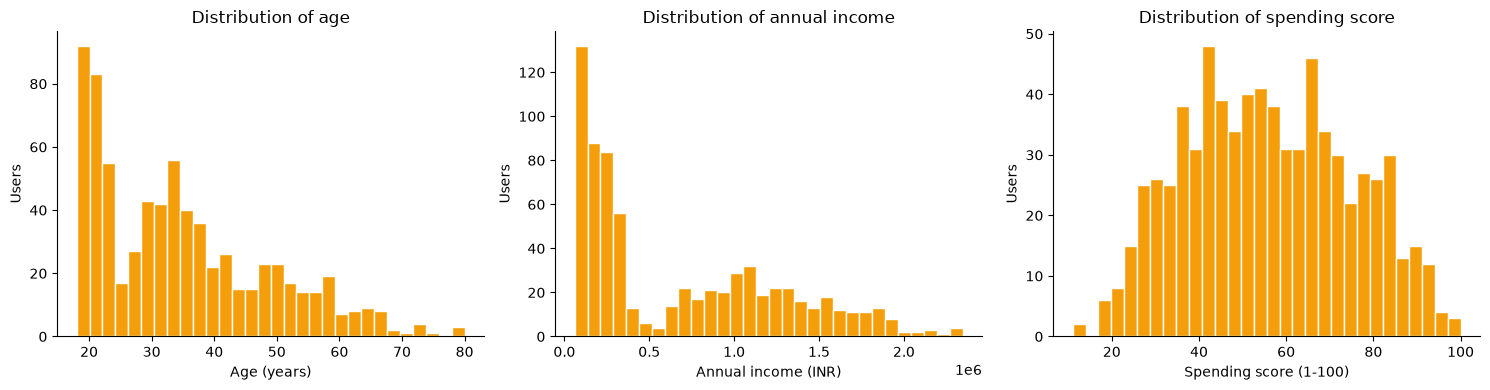

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, column, label in zip(axes, ["age", "annual_income", "spending_score"],
                             ["Age (years)", "Annual income (INR)", "Spending score (1-100)"]):
    ax.hist(raw[column].dropna(), bins=30, color="#F59E0B", edgecolor="white")
    ax.set_xlabel(label)
    ax.set_ylabel("Users")
    ax.set_title(f"Distribution of {label.split(' (')[0].lower()}")
save_fig("01_data_exploration")

## Step 4 — Clean the data

Raw marketing data is never perfect. We:
1. **remove exact duplicate rows** (the same user recorded twice would be counted twice by k-means);
2. **fix inconsistent values** (`"M"`, `"male"`, `" m"` → `Male`; `"DELHI"`, `"mumbai "` → `Delhi`, `Mumbai`; `"Bangalore"` → `Bengaluru`; lower-case channels);
3. **handle missing values** — numeric columns are filled with the **median** (robust to outliers), categorical columns with the **mode**, and missing interests are labelled `Not Specified`.

In [7]:
clean = raw.drop_duplicates().copy()

# --- fix inconsistent categorical values ---
clean["gender"] = clean["gender"].str.strip().str[0].str.upper().map({"M": "Male", "F": "Female"})
clean["city"] = clean["city"].str.strip().str.title().replace({"Bangalore": "Bengaluru"})
channel_names = ["WhatsApp", "Push Notification", "SMS", "Email", "Instagram", "YouTube",
                 "Facebook", "Google Search", "LinkedIn"]
clean["preferred_channel"] = clean["preferred_channel"].str.strip().str.lower().map(
    {name.lower(): name for name in channel_names})

# --- handle missing values ---
for column in ["age", "annual_income", "avg_order_value"]:
    clean[column] = clean[column].fillna(clean[column].median())
for column in ["gender", "preferred_channel"]:
    clean[column] = clean[column].fillna(clean[column].mode()[0])
clean["interests"] = clean["interests"].fillna("Not Specified")
clean["age"] = clean["age"].astype(int)

before_after = pd.DataFrame({
    "before": [raw.shape[0], raw.duplicated().sum(), raw.isna().sum().sum(),
               raw["gender"].nunique(), raw["city"].nunique(), raw["preferred_channel"].nunique()],
    "after": [clean.shape[0], clean.duplicated().sum(), clean.isna().sum().sum(),
              clean["gender"].nunique(), clean["city"].nunique(), clean["preferred_channel"].nunique()],
}, index=["rows", "duplicate rows", "missing cells", "gender spellings", "city spellings", "channel spellings"])
before_after

,before,after
rows,740,720
duplicate rows,20,0
missing cells,94,0
gender spellings,10,2
city spellings,28,10
channel spellings,18,9


In [8]:
clean.info()

<class 'pandas.DataFrame'>
Index: 720 entries, 0 to 739
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               720 non-null    str    
 1   age                       720 non-null    int64  
 2   gender                    720 non-null    str    
 3   occupation                720 non-null    str    
 4   education                 720 non-null    str    
 5   annual_income             720 non-null    float64
 6   website_visits_per_month  720 non-null    float64
 7   purchase_frequency        720 non-null    float64
 8   avg_order_value           720 non-null    float64
 9   spending_score            720 non-null    float64
 10  preferred_channel         720 non-null    str    
 11  interests                 720 non-null    str    
 12  city                      720 non-null    str    
 13  state                     720 non-null    str    
 14  country                   

## Step 5 — Select the features used for segmentation

k-means works on numbers, so we cluster on the six numeric attributes that describe *who the user is* and *how they behave*. Categorical columns (channel, interests, occupation, city) are not used for clustering. We use them afterwards to **describe** each segment, which is how personas get their flavour.

In [9]:
features = ["age", "annual_income", "spending_score", "purchase_frequency",
            "website_visits_per_month", "avg_order_value"]
X = clean[features]
X.describe().round(1)

,age,annual_income,spending_score,purchase_frequency,website_visits_per_month,avg_order_value
count,720.0,720.0,720.0,720.0,720.0,720.0
mean,34.8,670341.7,56.0,7.2,15.4,1376.5
std,13.5,579610.5,19.1,4.9,7.9,1495.1
min,18.0,60000.0,11.0,1.0,1.0,100.0
25%,23.0,168000.0,41.0,4.0,9.0,289.0
50%,33.0,361000.0,55.0,6.0,14.0,483.0
75%,42.0,1113000.0,70.0,10.0,22.0,1997.2
max,80.0,2346000.0,100.0,25.0,38.0,6878.0


## Step 6 — Normalise the features with `StandardScaler`

Income is in lakhs of rupees while age is in tens, so unscaled k-means would be dominated by income. `StandardScaler` rescales each feature to mean 0 and standard deviation 1: `z = (x - mean) / std`.

In [11]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features, index=X.index)

summary = pd.concat({"before (mean)": X.mean(), "before (std)": X.std(),
                     "after (mean)": X_scaled.mean(), "after (std)": X_scaled.std()}, axis=1)
summary.round(2)

,before (mean),before (std),after (mean),after (std)
age,34.82,13.52,-0.0,1.0
annual_income,670341.67,579610.45,0.0,1.0
spending_score,55.99,19.06,-0.0,1.0
purchase_frequency,7.25,4.90,0.0,1.0
website_visits_per_month,15.37,7.92,-0.0,1.0
avg_order_value,1376.48,1495.11,-0.0,1.0


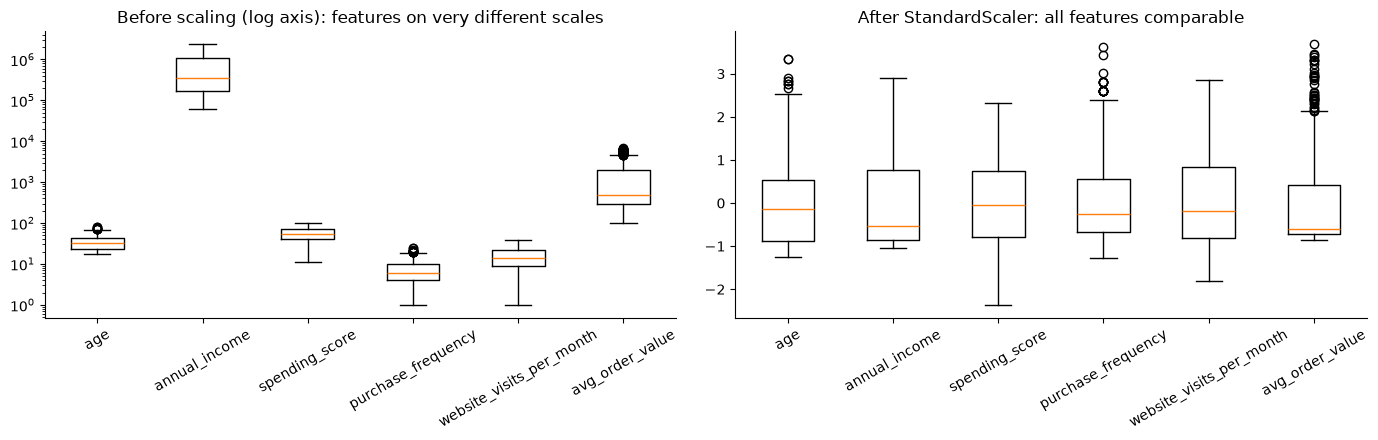

In [12]:
fig, (left, right) = plt.subplots(1, 2, figsize=(14, 4.5))
left.boxplot([X[c] for c in features], tick_labels=features)
left.set_yscale("log")
left.set_title("Before scaling (log axis): features on very different scales")
right.boxplot([X_scaled[c] for c in features], tick_labels=features)
right.set_title("After StandardScaler: all features comparable")
for ax in (left, right):
    ax.tick_params(axis="x", rotation=30)
save_fig("02_scaling_before_after")

## Step 7 — Apply k-means to group customers into segments

k-means picks *k* centroids, assigns every customer to the nearest centroid, recomputes the centroids and repeats until assignments stop changing. Since *k* must be chosen in advance, we compare two standard diagnostics for k = 2…10:

* **Elbow method** — inertia (within-cluster sum of squares) always falls as k grows; we look for the "elbow" where extra clusters stop paying off.
* **Silhouette score** — how well each point fits its own cluster versus the next nearest (−1 to 1, higher is better).

In [13]:
k_values = range(2, 11)
inertias, silhouettes = [], []
for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_scaled, model.labels_))

k_scores = pd.DataFrame({"k": list(k_values), "inertia": inertias, "silhouette": silhouettes}).round(3)
k_scores

,k,inertia,silhouette
0,2,2494.738,0.408
1,3,1637.899,0.472
2,4,1277.814,0.469
3,5,934.615,0.433
4,6,871.319,0.374
5,7,818.027,0.299
6,8,769.296,0.258
7,9,747.926,0.243
8,10,708.259,0.224


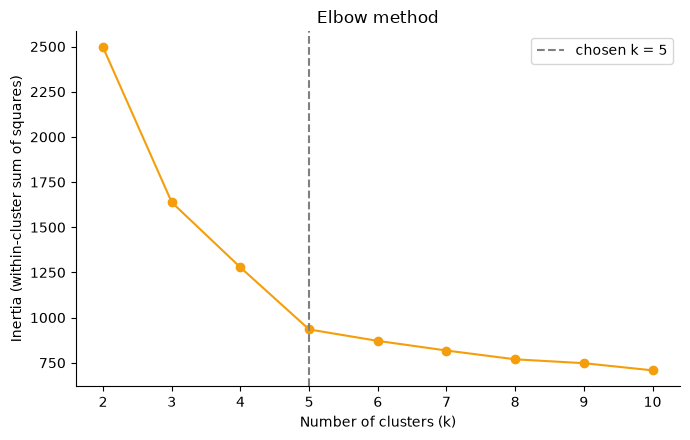

In [14]:
plt.figure(figsize=(7, 4.5))
plt.plot(k_scores["k"], k_scores["inertia"], marker="o", color="#F59E0B")
plt.axvline(5, linestyle="--", color="grey", label="chosen k = 5")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow method")
plt.legend()
save_fig("03_elbow")

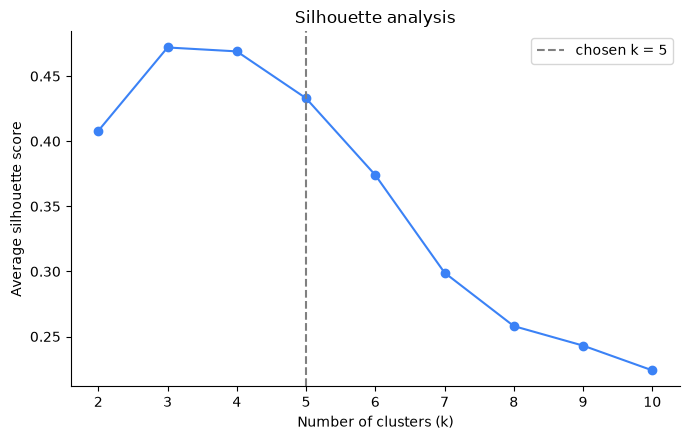

In [16]:
plt.figure(figsize=(7, 4.5))
plt.plot(k_scores["k"], k_scores["silhouette"], marker="o", color="#3B82F6")
plt.axvline(5, linestyle="--", color="grey", label="chosen k = 5")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Average silhouette score")
plt.title("Silhouette analysis")
plt.legend()
save_fig("04_silhouette")

### Choosing k

* **Elbow:** inertia drops steeply up to k = 5 and flattens afterwards, so the elbow sits around **k = 5**.
* **Silhouette:** the score is highest at k = 3 (≈ 0.47) and k = 4 (≈ 0.47) and is still a healthy ≈ 0.43 at k = 5, before falling sharply for k ≥ 6. This means k = 5 is still well separated but not the mathematical maximum.
* **Marketing usefulness:** k = 3 merges very different audiences (for example students with outdoor workers). k = 5 gives distinct, actionable personas whose channels and interests differ, and it is the last k before the silhouette collapses.

We therefore choose **k = 5**, a deliberate trade-off between statistical separation and persona usefulness. Final model below uses the same `random_state` and `n_init` as the search.

In [17]:
K = 5
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
clean["raw_cluster"] = kmeans.labels_

# k-means numbers clusters arbitrarily; renumber them 1..5 by ascending mean income so
# "Segment 1" is always the lowest-income group and the labelling is stable and readable
income_order = clean.groupby("raw_cluster")["annual_income"].mean().sort_values().index
segment_of = {raw_id: rank + 1 for rank, raw_id in enumerate(income_order)}
clean["segment"] = clean["raw_cluster"].map(segment_of)

print(f"Final silhouette score (k={K}): {silhouette_score(X_scaled, kmeans.labels_):.3f}")
clean["segment"].value_counts().sort_index().rename("customers")

Final silhouette score (k=5): 0.433


segment
1    200
2    171
3    165
4     75
5    109
Name: customers, dtype: int64

## Step 8 — Visualise the clusters

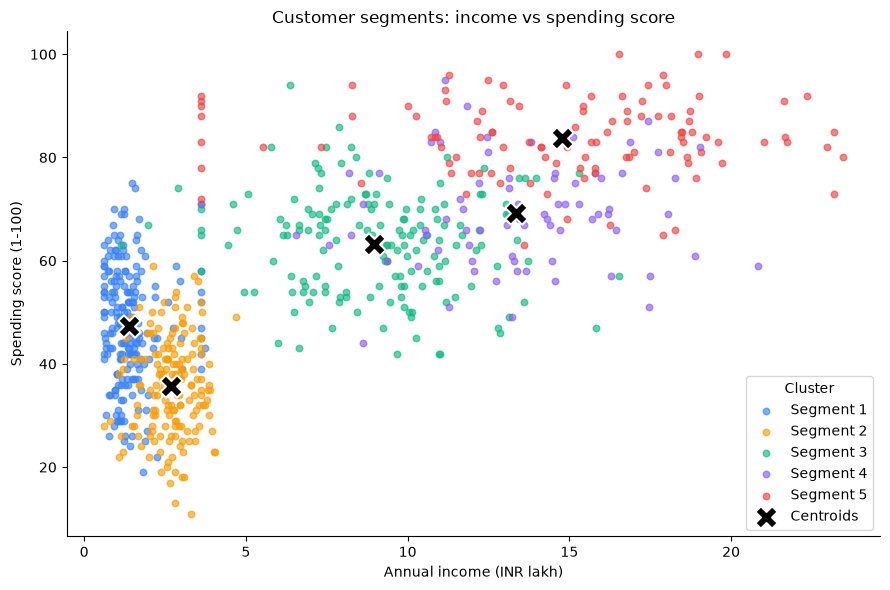

In [18]:
# centroids are computed in scaled space, so convert them back to real units for plotting
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
centroids["segment"] = centroids.index.map(segment_of)
centroids = centroids.sort_values("segment").set_index("segment")

plt.figure(figsize=(9, 6))
for segment, group in clean.groupby("segment"):
    plt.scatter(group["annual_income"] / 1e5, group["spending_score"], s=22, alpha=0.65,
                color=SEGMENT_COLOURS[segment - 1], label=f"Segment {segment}")
plt.scatter(centroids["annual_income"] / 1e5, centroids["spending_score"], marker="X", s=260,
            color="black", edgecolor="white", linewidth=1.5, label="Centroids", zorder=5)
plt.xlabel("Annual income (INR lakh)")
plt.ylabel("Spending score (1-100)")
plt.title("Customer segments: income vs spending score")
plt.legend(title="Cluster")
save_fig("05_clusters_scatter")

/home/dharmikchandel/projects/heatwave-monitor/digital-marketing/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


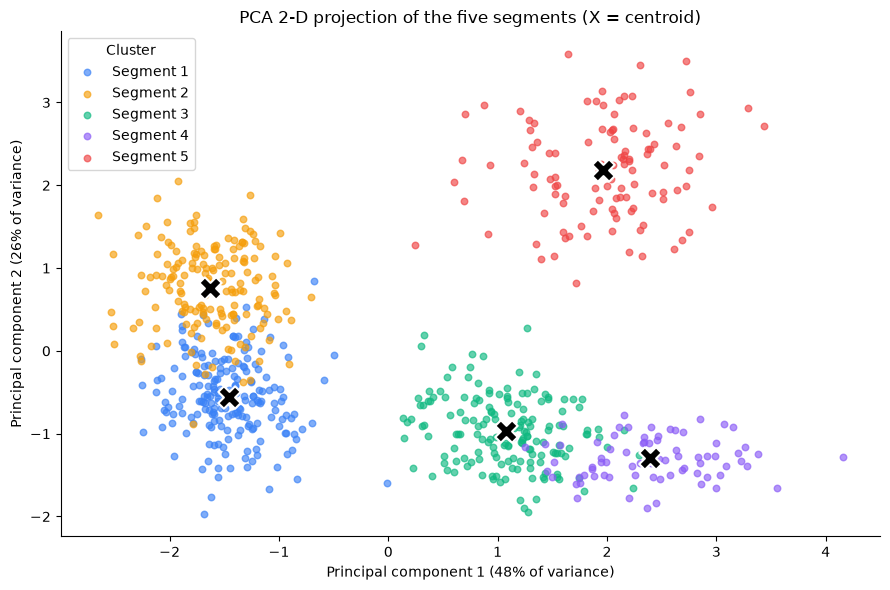

In [19]:
# PCA squeezes all six scaled features into 2 axes so we can see the whole clustering at once
pca = PCA(n_components=2, random_state=RANDOM_STATE)
points = pca.fit_transform(X_scaled)
centre_points = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(9, 6))
for segment in range(1, K + 1):
    mask = (clean["segment"] == segment).to_numpy()
    plt.scatter(points[mask, 0], points[mask, 1], s=22, alpha=0.65,
                color=SEGMENT_COLOURS[segment - 1], label=f"Segment {segment}")
for x, y in centre_points:
    plt.scatter(x, y, marker="X", s=260, color="black", edgecolor="white", linewidth=1.5, zorder=5)
plt.xlabel(f"Principal component 1 ({pca.explained_variance_ratio_[0]:.0%} of variance)")
plt.ylabel(f"Principal component 2 ({pca.explained_variance_ratio_[1]:.0%} of variance)")
plt.title("PCA 2-D projection of the five segments (X = centroid)")
plt.legend(title="Cluster")
save_fig("06_clusters_pca")

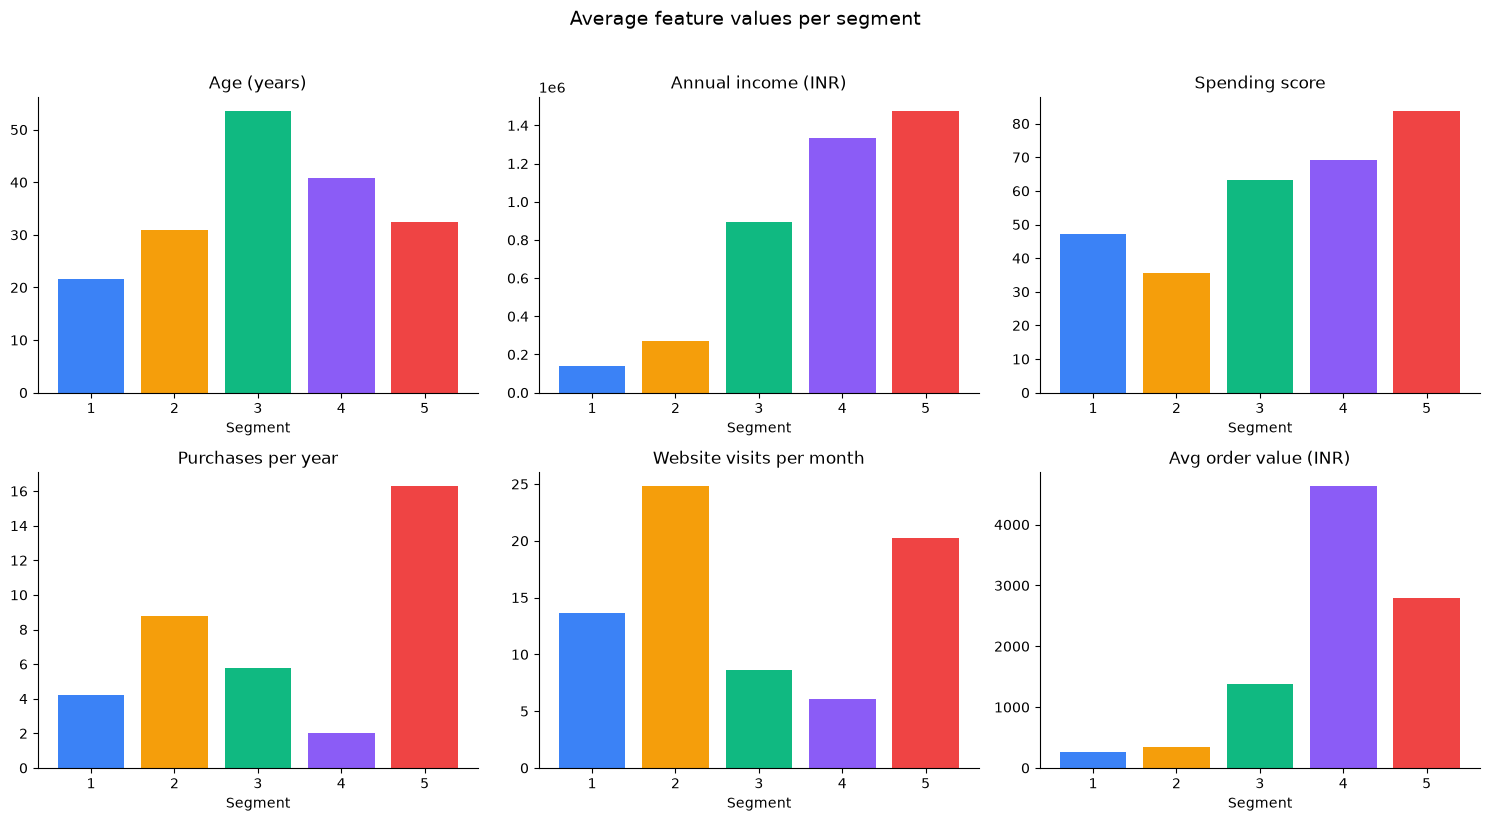

In [20]:
# bar charts of the mean of each feature per segment (in real units)
segment_means = clean.groupby("segment")[features].mean()
titles = ["Age (years)", "Annual income (INR)", "Spending score", "Purchases per year",
          "Website visits per month", "Avg order value (INR)"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, column, title in zip(axes.ravel(), features, titles):
    ax.bar(segment_means.index.astype(str), segment_means[column], color=SEGMENT_COLOURS)
    ax.set_title(title)
    ax.set_xlabel("Segment")
fig.suptitle("Average feature values per segment", y=1.02, fontsize=14)
save_fig("07_segment_feature_means")

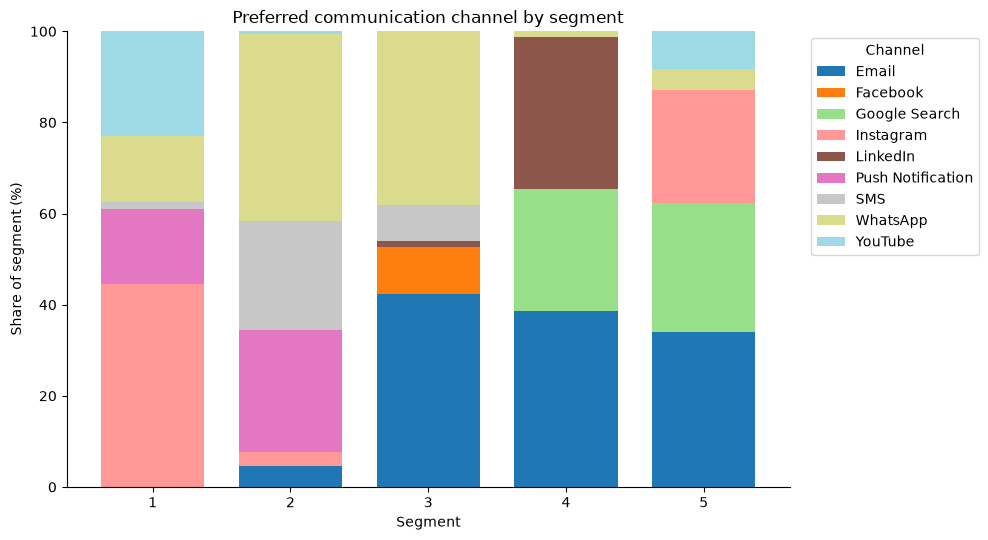

In [21]:
# which channel does each segment prefer?
channel_mix = pd.crosstab(clean["segment"], clean["preferred_channel"], normalize="index") * 100
channel_mix.plot(kind="bar", stacked=True, figsize=(10, 5.5), colormap="tab20", width=0.75)
plt.xlabel("Segment")
plt.ylabel("Share of segment (%)")
plt.title("Preferred communication channel by segment")
plt.xticks(rotation=0)
plt.legend(title="Channel", bbox_to_anchor=(1.02, 1), loc="upper left")
save_fig("08_channel_by_segment")

## Step 9 — Analyse each cluster and build the customer personas

First we build the **cluster profile table** — numeric means plus the most common (mode) channel, interests, occupations and cities. The personas below are written from these numbers.

In [23]:
def top_values(series, n=3):
    return ", ".join(series.value_counts().head(n).index)

profile_rows = []
for segment, group in clean.groupby("segment"):
    interests = group["interests"].str.split("; ").explode()
    interests = interests[interests != "Not Specified"]
    profile_rows.append({
        "segment": segment,
        "customers": len(group),
        "pct_of_customers": round(100 * len(group) / len(clean), 1),
        "avg_age": round(group["age"].mean(), 1),
        "avg_annual_income": round(group["annual_income"].mean()),
        "avg_spending_score": round(group["spending_score"].mean(), 1),
        "avg_purchases_per_year": round(group["purchase_frequency"].mean(), 1),
        "avg_visits_per_month": round(group["website_visits_per_month"].mean(), 1),
        "avg_order_value": round(group["avg_order_value"].mean()),
        "pct_female": round(100 * (group["gender"] == "Female").mean()),
        "top_channels": top_values(group["preferred_channel"], 2),
        "top_interests": top_values(interests, 3),
        "top_occupations": top_values(group["occupation"], 3),
        "top_cities": top_values(group["city"], 3),
    })
profile = pd.DataFrame(profile_rows).set_index("segment")
profile.T

segment,1,2,3,4,5
customers,200,171,165,75,109
pct_of_customers,27.8,23.8,22.9,10.4,15.1
avg_age,21.6,31.0,53.6,40.9,32.5
avg_annual_income,138020,269725,895970,1335907,1476064
avg_spending_score,47.3,35.6,63.3,69.2,83.8
avg_purchases_per_year,4.2,8.8,5.8,2.0,16.3
avg_visits_per_month,13.7,24.8,8.6,6.1,20.2
avg_order_value,258,349,1378,4632,2797
pct_female,46,14,56,48,45
top_channels,"Instagram, YouTube","WhatsApp, Push Notification","Email, WhatsApp","Email, LinkedIn","Email, Google Search"


### Personas

Persona *names and narrative fields* (goals, pain points, strategy) are written by the analyst from the profile above, while *age group, income level and spending behaviour* are generated directly from the cluster numbers so they can never drift from the data.

In [24]:
persona_text = {
    1: dict(
        persona_name="Budget-Conscious Campus Commuter",
        shopping_preferences="Low-ticket, impulse-friendly purchases; hunts for discounts and free tools; buys only when the value is obvious.",
        goals="Stay cool and safe on the daily commute, know when it is too hot to be outside, get quick tips they can share with friends.",
        pain_points="Tight budget; heat information arrives too late or buried in text; does not want to pay for something the free dashboard already gives.",
        marketing_strategy="Social media + short video: Instagram Reels / YouTube Shorts with 'is it too hot today?' tips; make the shareable PNG heat report a viral loop; push notifications for the daily risk tier; campus ambassador and student-discount hydration affiliate offers.",
    ),
    2: dict(
        persona_name="Outdoor Frontline Worker",
        shopping_preferences="Practical, essential items (electrolytes, cooling towels, caps); buys often but small; values price and durability.",
        goals="Work safely through peak heat, know exactly when to take breaks and hydrate, protect income by avoiding heat illness.",
        pain_points="Long exposure with no shade; low income; limited data and time to read; prefers simple, local-language messages.",
        marketing_strategy="Direct messaging: WhatsApp broadcast lists and SMS/push alerts whenever the risk tier reaches Danger; Hindi/Marathi micro-content built from the Safety page; partnerships with gig platforms and contractors; local-SEO for 'heat index today <city>'; retargeting with low-cost hydration bundles.",
    ),
    3: dict(
        persona_name="Health-Conscious Family Guardian",
        shopping_preferences="Quality and trust over price; researches before buying; purchases home-cooling and health products in larger baskets.",
        goals="Protect elderly relatives and children during heatwaves, recognise heat-illness symptoms early, plan a safe household routine.",
        pain_points="Unsure which symptoms are serious; overwhelmed by conflicting advice; worries about vulnerable family members.",
        marketing_strategy="Content marketing + email: a weekly 'family heat-safety' email digest; long-form guides on heat-illness stages (from the Safety page) optimised for SEO on searches like 'heat stroke symptoms elderly'; Facebook community posts; retargeting ads for home-cooling and health products.",
    ),
    4: dict(
        persona_name="Institutional Heat Planner",
        shopping_preferences="Rare but high-value purchases (reports, subscriptions, bulk supplies); needs credible, citable sources before committing.",
        goals="Schedule events and shifts safely, build heat-action plans for staff, students or citizens, back decisions with defensible data.",
        pain_points="Needs proof of methodology; time-poor; requires exportable, shareable reports for stakeholders.",
        marketing_strategy="B2B content and paid search: LinkedIn thought-leadership using the Methodology (About) page; Google Search ads on 'heat action plan' terms; email nurture drip that ends in a premium report / API offer; webinars with municipal and school partners.",
    ),
    5: dict(
        persona_name="Active Urban Fitness Enthusiast",
        shopping_preferences="Frequent, premium purchases (wearables, sports nutrition, gear); brand-aware and influenced by peers and creators.",
        goals="Train outdoors safely and consistently, pick the best hour to run or ride, get the most from every session in hot weather.",
        pain_points="Heat ruins training plans; unsure when conditions cross from tough to risky; wants data, not generic warnings.",
        marketing_strategy="Email + paid search, amplified on social: a personalised 'best hour to train' email built from the hourly forecast; Google Search ads and retargeting for wearables and hydration gear; premium-tier upsell; Instagram/YouTube partnerships with running clubs and fitness creators as a secondary channel.",
    ),
}


def age_group(group):
    return f"{int(group['age'].quantile(0.1))}-{int(group['age'].quantile(0.9))} years (average {group['age'].mean():.0f})"


def income_level(income):
    label = "Low" if income < 300_000 else "Lower-middle" if income < 600_000 else "Upper-middle" if income < 1_200_000 else "High"
    return f"{label} (about INR {income / 100_000:.1f} lakh per year)"


def spending_behaviour(row):
    level = "High" if row["avg_spending_score"] >= 75 else "Moderate" if row["avg_spending_score"] >= 55 else "Low"
    return (f"{level}: spending score {row['avg_spending_score']:.0f}/100, about {row['avg_purchases_per_year']:.0f} purchases "
            f"a year at roughly INR {row['avg_order_value']:,.0f} each, {row['avg_visits_per_month']:.0f} site visits a month")


persona_rows = []
for segment, row in profile.iterrows():
    group = clean[clean["segment"] == segment]
    persona_rows.append({
        "segment": segment,
        "persona_name": persona_text[segment]["persona_name"],
        "customers": row["customers"],
        "pct_of_customers": row["pct_of_customers"],
        "age_group": age_group(group),
        "income_level": income_level(row["avg_annual_income"]),
        "spending_behavior": spending_behaviour(row),
        "shopping_preferences": persona_text[segment]["shopping_preferences"],
        "interests": row["top_interests"],
        "goals": persona_text[segment]["goals"],
        "pain_points": persona_text[segment]["pain_points"],
        "preferred_channels": row["top_channels"],
        "marketing_strategy": persona_text[segment]["marketing_strategy"],
    })
personas = pd.DataFrame(persona_rows)
personas.head(0)

,segment,persona_name,customers,pct_of_customers,age_group,income_level,spending_behavior,shopping_preferences,interests,goals,pain_points,preferred_channels,marketing_strategy


In [25]:
for _, persona in personas.iterrows():
    print(f"SEGMENT {persona['segment']}: {persona['persona_name']}  "
          f"({persona['customers']} users, {persona['pct_of_customers']}%)")
    for field in ["age_group", "income_level", "spending_behavior", "shopping_preferences", "interests",
                  "goals", "pain_points", "preferred_channels", "marketing_strategy"]:
        print(f"  {field.replace('_', ' ').title():<22}: {persona[field]}")
    print()

SEGMENT 1: Budget-Conscious Campus Commuter  (200 users, 27.8%)
  Age Group             : 18-25 years (average 22)
  Income Level          : Low (about INR 1.4 lakh per year)
  Spending Behavior     : Low: spending score 47/100, about 4 purchases a year at roughly INR 258 each, 14 site visits a month
  Shopping Preferences  : Low-ticket, impulse-friendly purchases; hunts for discounts and free tools; buys only when the value is obvious.
  Interests             : Fitness, Campus Life, Weather Trends
  Goals                 : Stay cool and safe on the daily commute, know when it is too hot to be outside, get quick tips they can share with friends.
  Pain Points           : Tight budget; heat information arrives too late or buried in text; does not want to pay for something the free dashboard already gives.
  Preferred Channels    : Instagram, YouTube
  Marketing Strategy    : Social media + short video: Instagram Reels / YouTube Shorts with 'is it too hot today?' tips; make the shareable

## Step 10 — Summarise the personas and suggest digital marketing strategies

The table below is saved to `outputs/personas.csv` (persona fields) and combined with the numeric cluster profile.

In [26]:
persona_table = personas.merge(
    profile.drop(columns=["customers", "pct_of_customers", "top_channels", "top_interests"]).reset_index(),
    on="segment")
persona_table.to_csv(ROOT / "outputs" / "personas.csv", index=False)

summary_view = personas[["segment", "persona_name", "customers", "pct_of_customers", "preferred_channels", "interests"]]
summary_view

,segment,persona_name,customers,pct_of_customers,preferred_channels,interests
0,1,Budget-Conscious Campus Commuter,200,27.8,"Instagram, YouTube","Fitness, Campus Life, Weather Trends"
1,2,Outdoor Frontline Worker,171,23.8,"WhatsApp, Push Notification","Heat Alerts, Work Safety, Hydration"
2,3,Health-Conscious Family Guardian,165,22.9,"Email, WhatsApp","Home Cooling, Elderly Care, Health Advisories"
3,4,Institutional Heat Planner,75,10.4,"Email, LinkedIn","Public Health, Heat Action Plans, Climate Data"
4,5,Active Urban Fitness Enthusiast,109,15.1,"Email, Google Search","Fitness, Running, Travel"


In [27]:
strategy_map = pd.DataFrame({
    "Persona": personas["persona_name"],
    "Best channels": personas["preferred_channels"],
    "Core tactic": personas["marketing_strategy"].str.split(":").str[0],
}, index=personas["segment"])
strategy_map

,Persona,Best channels,Core tactic
segment,,,
1,Outdoor Frontline Worker,"WhatsApp, Push Notification",Direct messaging
2,Health-Conscious Family Guardian,"Email, WhatsApp",Content marketing + email
3,Institutional Heat Planner,"Email, LinkedIn",B2B content and paid search
4,Active Urban Fitness Enthusiast,"Email, Google Search","Email + paid search, amplified on social"
5,NaN,NaN,NaN


### Result

Cleaned data (duplicates removed, missing values filled, labels standardised) was scaled and segmented with k-means (k = 5) into five personas that differ clearly in age, income, spending, channel and interests. The full lab write-up is in `outputs/report.md`.